## 1. Configurações do Ambiente

In [4]:
# Importando bibliotecas 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import mlflow
import mlflow.sklearn
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, classification_report

## 2. Carregamento e Visualização dos Dados

In [5]:
# Carregando o dataset
path = '../data/raw/Telco_customer_churn.xlsx'
df = pd.read_excel(path)

# E para salvar o CSV, a mesma lógica:
df.to_csv('../data/raw/Telco_customer_churn.csv', index=False)
print("CSV salvo na pasta data")

# Visualizando as primeiras linhas do dataset
print(f"Shape dos dados: {df.shape}")
print(f"Primeiras linhas do dataset:")
display(df.head(10))

CSV salvo na pasta data
Shape dos dados: (7043, 33)
Primeiras linhas do dataset:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,7156-MXBJE,1,United States,California,San Diego,92127,"33.017518, -117.118456",33.017518,-117.118456,Female,...,One year,No,Credit card (automatic),85.10,3662.25,No,0,5,2319,NaN
1,9058-HRZSV,1,United States,California,Baldwin Park,91706,"34.098275, -117.967399",34.098275,-117.967399,Female,...,Month-to-month,No,Electronic check,94.40,6126.15,No,0,7,5348,NaN
2,4522-AKYLR,1,United States,California,Chino Hills,91709,"33.942895, -117.725644",33.942895,-117.725644,Female,...,Month-to-month,Yes,Electronic check,54.80,731.3,No,0,7,5557,NaN
3,3146-MSEGF,1,United States,California,Paramount,90723,"33.897122, -118.164432",33.897122,-118.164432,Female,...,Two year,Yes,Credit card (automatic),88.05,6425.65,No,0,8,6102,NaN
4,7554-NEWDD,1,United States,California,Long Beach,90815,"33.797638, -118.11662",33.797638,-118.116620,Male,...,Two year,No,Bank transfer (automatic),25.70,251.6,No,0,8,3611,NaN
5,4767-HZZHQ,1,United States,California,Redondo Beach,90277,"33.830453, -118.384565",33.830453,-118.384565,Male,...,Month-to-month,No,Bank transfer (automatic),82.05,2570.2,No,0,9,5036,NaN
6,5876-QMYLD,1,United States,California,Earp,92242,"34.137742, -114.36514",34.137742,-114.365140,Female,...,One year,No,Mailed check,20.05,415.1,No,0,9,3742,NaN
7,7606-BPHHN,1,United States,California,La Quinta,92253,"33.695532, -116.310571",33.695532,-116.310571,Male,...,Two year,Yes,Credit card (automatic),19.80,1468.75,No,0,9,5368,NaN
8,3170-NMYVV,1,United States,California,Compton,90222,"33.912246, -118.236773",33.912246,-118.236773,Female,...,Two year,No,Bank transfer (automatic),20.15,930.9,No,0,20,5849,NaN
9,2233-FAGXV,1,United States,California,Salton City,92275,"33.28156, -115.955541",33.281560,-115.955541,Female,...,Month-to-month,Yes,Mailed check,24.30,132.25,No,0,20,3181,NaN


In [6]:
# Informações gerais sobre o dataset
print("Informações gerais sobre o dataset:")
df.info()
print("Estatísticas descritivas para colunas numéricas:")
df.describe()

Informações gerais sobre o dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   o

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Análise de Missing Values

**Objetivo:** Identificar valores ausentes e entender seu padrão de distribuição

===BUSCA DE MISSING VALUES===

                    Coluna  Missing_Count  Missing_Percentage
Churn Reason  Churn Reason           5174               73.46


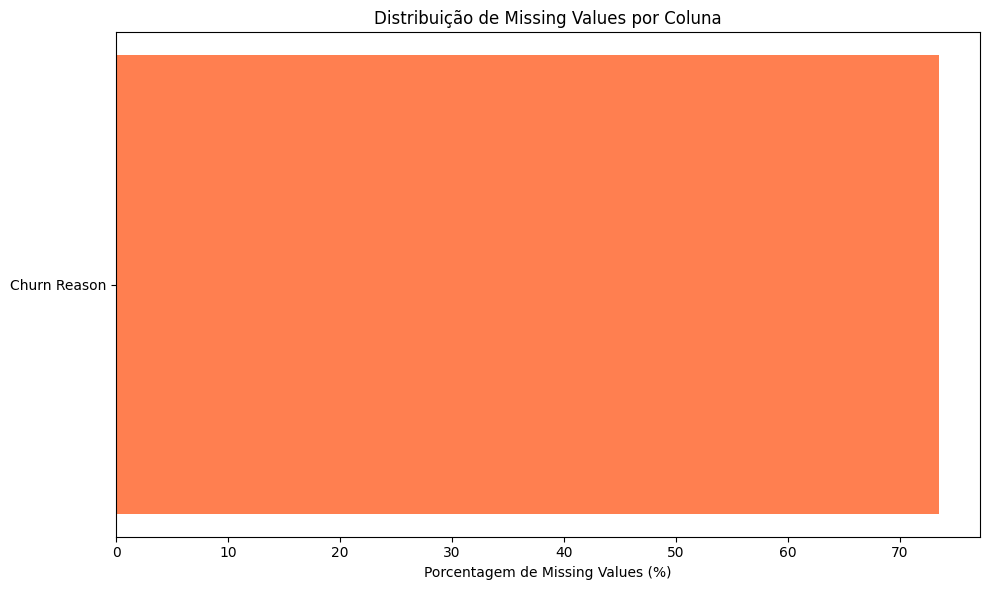

In [7]:
# Análise de valores ausentes
print("===BUSCA DE MISSING VALUES===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage':(df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)

    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum missing value encontrado!')


### 3.2 Análise da Variável Target


**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== Distribuição da variável target ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Porcentagem:
Sem Cancelamento (0): 73.46%
Com Cancelamento (1): 26.54%


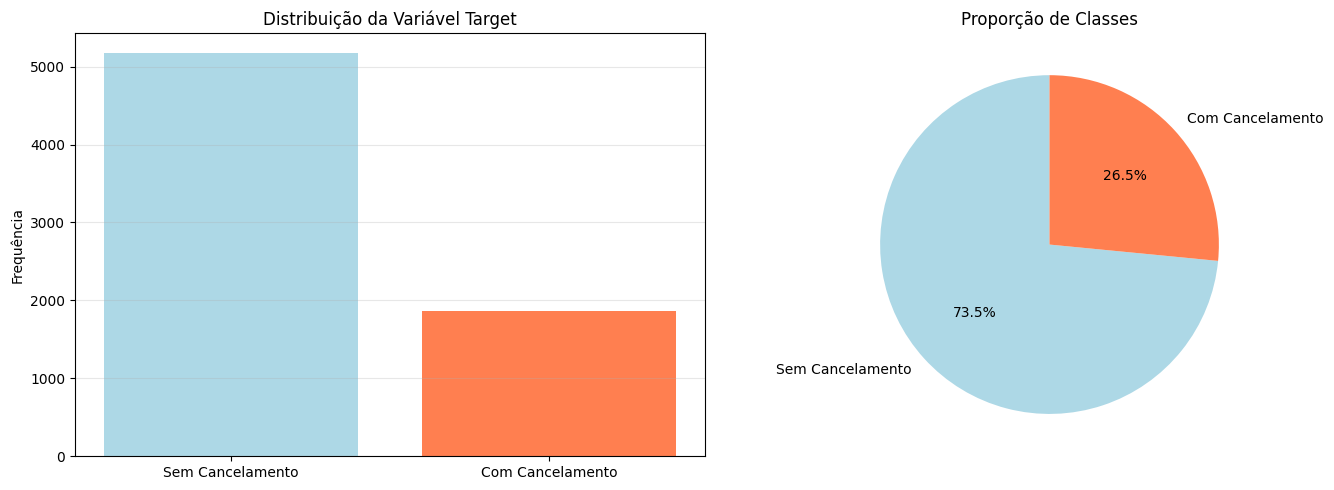


Ratio de balanceamento: 0.36
⚠️ A variável target está desbalanceada.


In [8]:
#renomeia a variável `churn` para `target`
df.rename(columns={'Churn Value': 'target'}, inplace=True)

# Target (0 = sem cancelamento, 1 = com cancelamento)
# No dataset original os valores > 0 indicam cancelamento
df['target'] = (df['target'] > 0).astype(int)

print("=== Distribuição da variável target ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True)* 100

print("Contagem:")
print(target_counts)
print("\nPorcentagem:")
for idx, pct in target_percentages.items():
    label = "Sem Cancelamento" if idx == 0 else "Com Cancelamento"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Sem Cancelamento', 'Com Cancelamento'], target_counts, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Sem Cancelamento', 'Com Cancelamento'],
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print(f"⚠️ A variável target está desbalanceada.")
else:
    print(f"✅ A variável target está relativamente balanceada.")

### 3.3 Análise de Outliers 

**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos utilizados:**
- **Z-Score**: Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização**: Boxplots para identificação visual

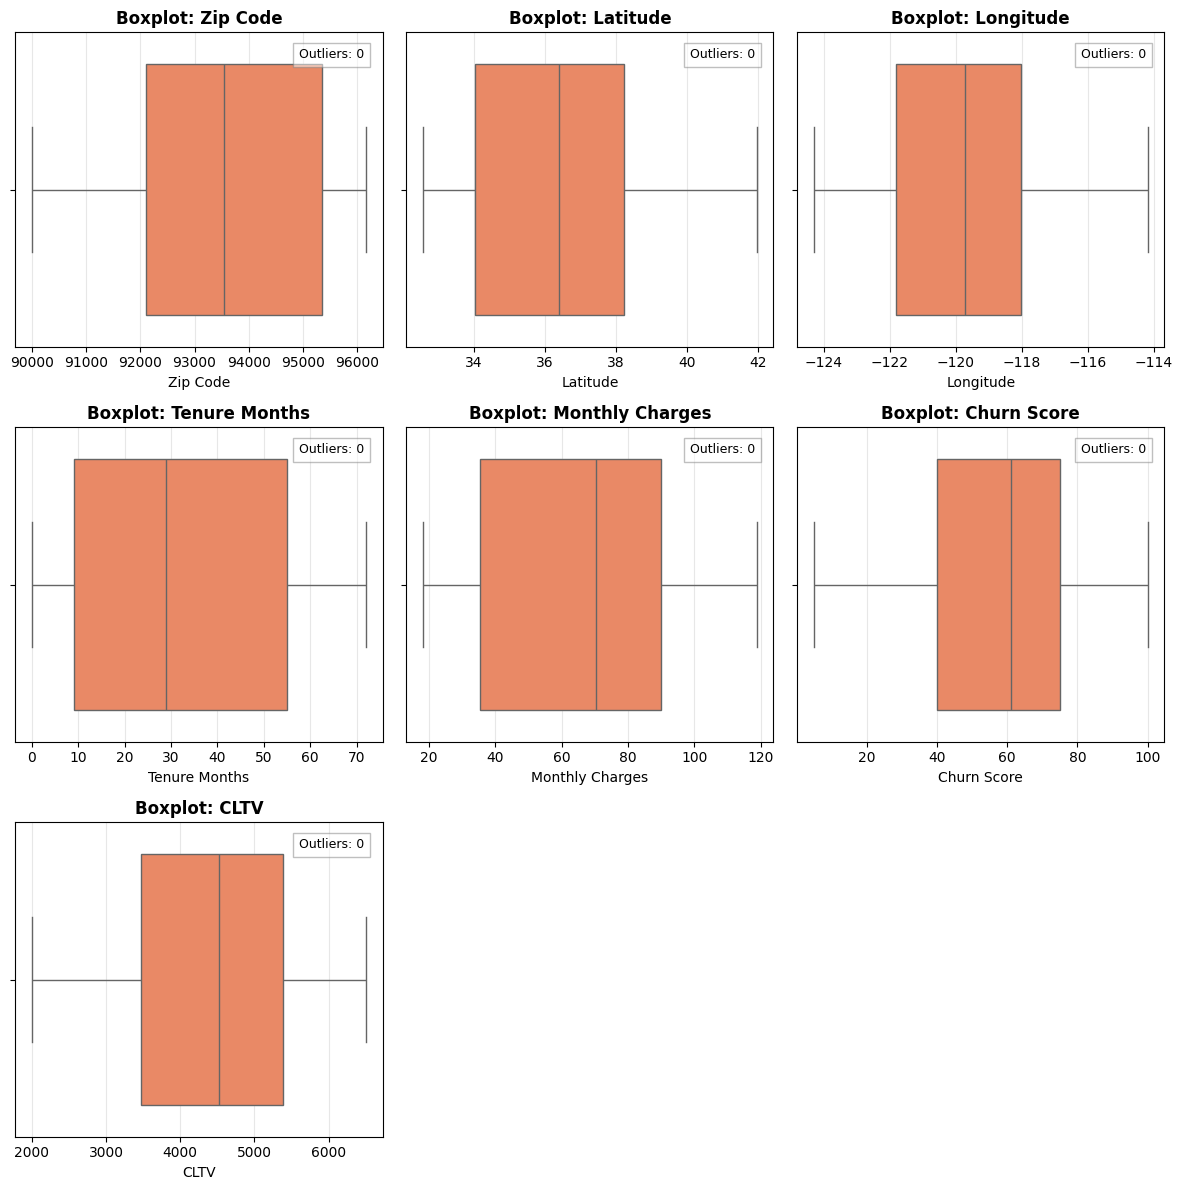

In [9]:
# Colunas numéricas (excluindo a variável target e id)

numeric_cols = df.select_dtypes(include=[np.number]).columns

# O errors='ignore' evita o KeyError caso o ID já tenha ficado de fora por ser string
to_drop = ['CustomerID', 'target', 'Count']
numeric_cols = numeric_cols.drop(to_drop, errors='ignore')

n = len(numeric_cols)
ncols= 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize =(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax= axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show() 


### 3.4 Análise de Anomalias e Valores Inválidos

**Objetivo:** Identificar valores que não fazem sentido no contexto de cancelamento

In [10]:
print("=== ANÁLISE DE ANOMALIAS: DATASET TELCO CHURN (IBM VERSION) ===\n")

anomalies = []

# 1. Ajuste de Tipagem e Strings Vazias em 'Total Charges'
if 'Total Charges' in df.columns:
    # Identifica strings vazias
    invalid_total = df[df['Total Charges'].astype(str).str.strip() == ""]
    if len(invalid_total) > 0:
        anomalies.append(f"Total Charges: {len(invalid_total)} casos vazios")
        print(f"⚠️ Total Charges: {len(invalid_total)} casos com strings vazias detectados.")
    
    # Converte para numérico (o espaço vira NaN)
    df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 2. Verificação de Intervalos Numéricos
numeric_checks = {
    'Tenure Months': (0, 72),
    'Monthly Charges': (15, 150), 
    'Churn Score': (0, 100),
    'CLTV': (2000, 7000)          
}

for col, (min_val, max_val) in numeric_checks.items():
    if col in df.columns:
        out_of_range = df[(df[col] < min_val) | (df[col] > max_val)]
        if not out_of_range.empty:
            anomalies.append(f"{col} fora do intervalo: {len(out_of_range)} casos")
            print(f"⚠️ {col}: {len(out_of_range)} casos fora do esperado ({min_val}-{max_val})")

# 3. Consistência Geográfica (Simples)
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    # Coordenadas aproximadas da Califórnia (onde esse dataset se baseia)
    geo_anomalies = df[(df['Latitude'] < 32) | (df['Latitude'] > 42) | 
                       (df['Longitude'] > -114) | (df['Longitude'] < -125)]
    if len(geo_anomalies) > 0:
        anomalies.append(f"Localização fora da CA: {len(geo_anomalies)} casos")

# 4. Validação de Churn Score vs Churn Value
# Se Churn Value é 1, o Churn Score deve ser alto (geralmente > 50)
if 'Churn Value' in df.columns and 'Churn Score' in df.columns:
    inconsistent_churn = df[(df['Churn Value'] == 1) & (df['Churn Score'] < 30)]
    if len(inconsistent_churn) > 0:
        anomalies.append(f"Inconsistência Churn Score/Value: {len(inconsistent_churn)} casos")
        print(f"⚠️ {len(inconsistent_churn)} casos com Churn Score muito baixo para um cliente que cancelou.")

# 5. Verificação de Duplicados e IDs
if 'CustomerID' in df.columns:
    dups_id = df['CustomerID'].duplicated().sum()
    if dups_id > 0:
        anomalies.append(f"IDs Duplicados: {dups_id} casos")
        print(f"❌ Erro Crítico: {dups_id} CustomerIDs duplicados encontrados!")

# Resumo Final
print(f"\n{'='*40}")
if not anomalies:
    print("✓ Dataset validado com sucesso!")
else:
    print(f"📊 Total de problemas encontrados: {len(anomalies)}")

=== ANÁLISE DE ANOMALIAS: DATASET TELCO CHURN (IBM VERSION) ===

⚠️ Total Charges: 11 casos com strings vazias detectados.

📊 Total de problemas encontrados: 1


### 3.5 Análise de Distribuições

**Objetivo:** Entender a distribuição das variáveis numéricas e identificar assimetrias

=== ANÁLISE DE ASSIMETRIA E CURTOSE (CONTÍNUAS) ===

         Coluna  Skewness  Kurtosis                   Distribuição
  Tenure Months     0.240    -1.387             Simétrica (Normal)
Monthly Charges    -0.221    -1.257             Simétrica (Normal)
  Total Charges     0.962    -0.232 Assimétrica Positiva (Direita)
    Churn Score    -0.090    -1.006             Simétrica (Normal)
           CLTV    -0.312    -0.934             Simétrica (Normal)


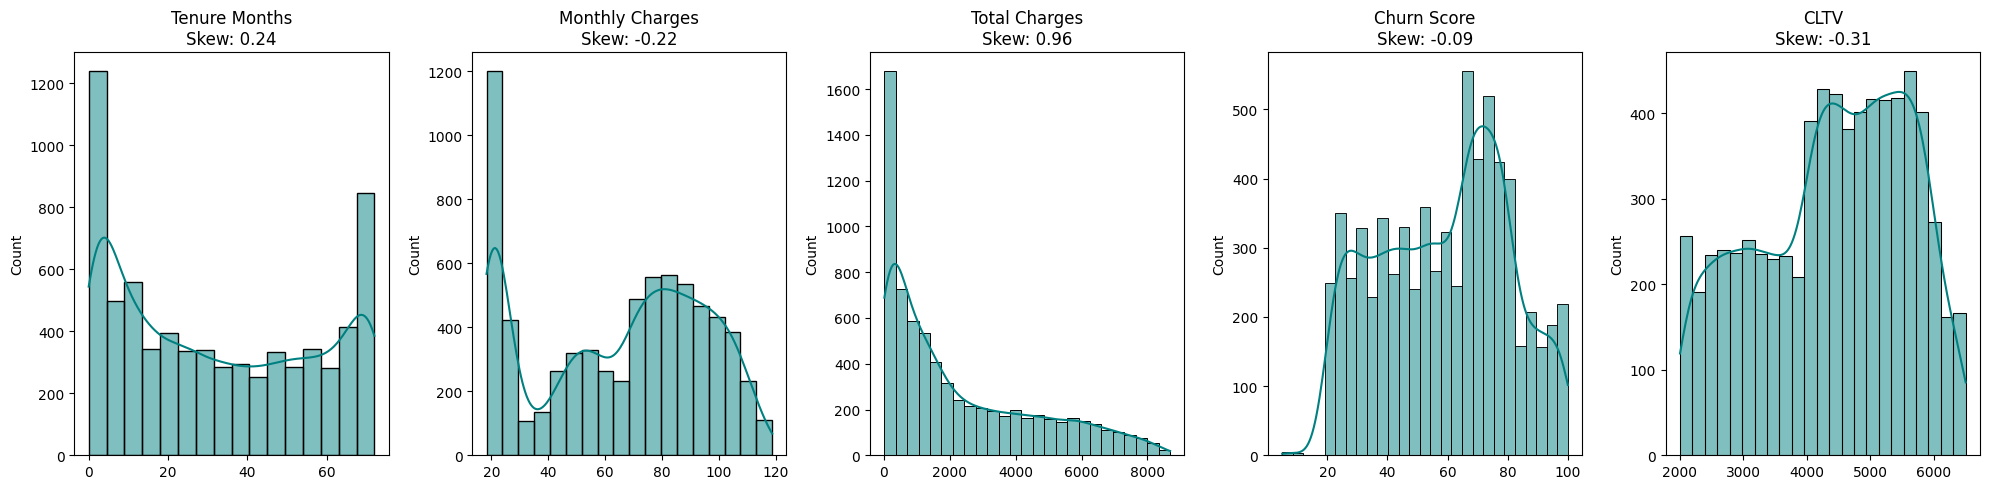

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garantir que as colunas principais são numéricas
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 2. Apenas colunas que fazem sentido para análise de distribuição
# Removemos IDs, CEPs e coordenadas
cols_para_dist = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']

print("=== ANÁLISE DE ASSIMETRIA E CURTOSE (CONTÍNUAS) ===\n")

dist_stats = []
for col in cols_para_dist:
    if col in df.columns:
        skew = df[col].skew()
        kurt = df[col].kurtosis()
        
        # Interpretação de Skewness
        if abs(skew) < 0.5: interp_skew = "Simétrica (Normal)"
        elif skew > 0.5: interp_skew = "Assimétrica Positiva (Direita)"
        else: interp_skew = "Assimétrica Negativa (Esquerda)"
        
        dist_stats.append({
            'Coluna': col,
            'Skewness': round(skew, 3),
            'Kurtosis': round(kurt, 3),
            'Distribuição': interp_skew
        })

print(pd.DataFrame(dist_stats).to_string(index=False))

# 3. Visualização Dinâmica
n_cols = len(cols_para_dist)
fig, axes = plt.subplots(1, n_cols, figsize=(20, 5))

for i, col in enumerate(cols_para_dist):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'{col}\nSkew: {df[col].skew():.2f}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### 3.6 Análise de Correlações

**Objetivo:** Identificar relações entre variáveis e detectar multicolinearidade

=== ANÁLISE DE ANOMALIAS E DOMÍNIO ===

Registros duplicados: 0

=== ANÁLISE DE ASSIMETRIA E CURTOSE ===

         Coluna  Skewness  Kurtosis Interpretação
  Tenure Months     0.240    -1.387        Normal
Monthly Charges    -0.221    -1.257        Normal
  Total Charges     0.963    -0.229       Direita
           CLTV    -0.312    -0.934        Normal


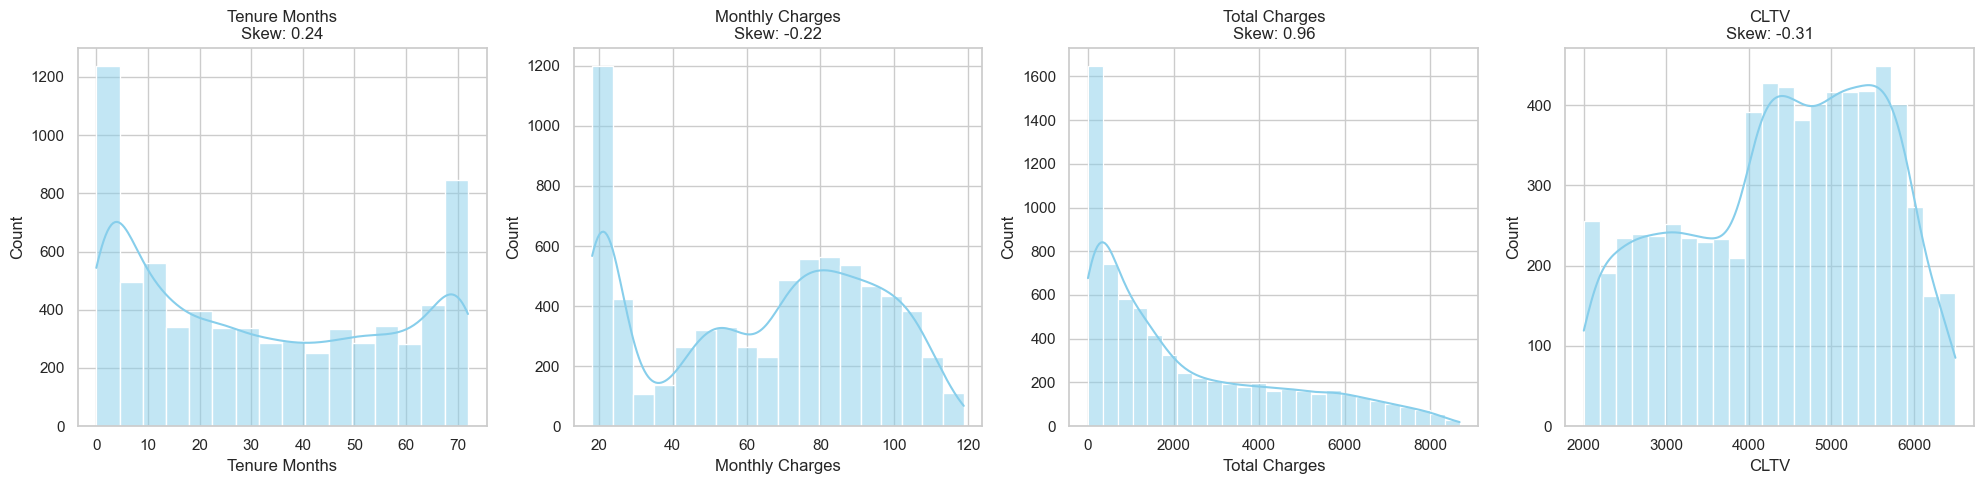


=== MATRIZ DE CORRELAÇÃO E MULTICOLINEARIDADE ===



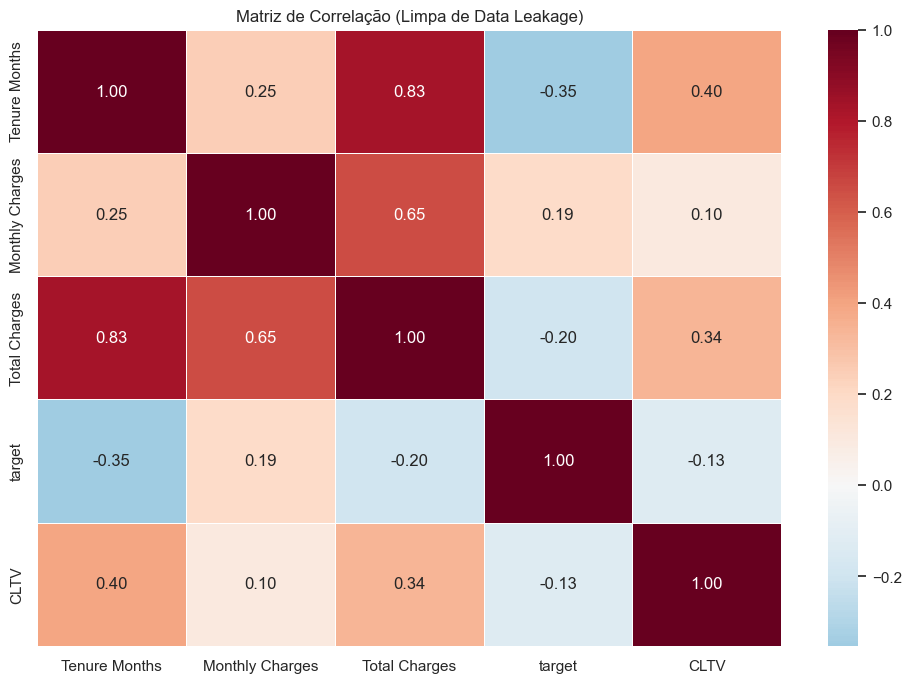

Correlação com o Target (Ordenada):
target             1.000000
Monthly Charges    0.193356
CLTV              -0.127463
Total Charges     -0.198324
Tenure Months     -0.352229
Name: target, dtype: float64

=== PARES COM ALTA CORRELAÇÃO (> 0.8) ===
              F1             F2   Corr
0  Tenure Months  Total Charges  0.826


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# =================================================================
# 1. CARREGAMENTO E LIMPEZA INICIAL
# =================================================================
# df = pd.read_csv('seu_arquivo.csv')

# Tratando 'Total Charges' (espaços vazios e tipagem)
if 'Total Charges' in df.columns:
    df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# Garantindo que o target está como numérico (0 e 1)
# Se você já renomeou Churn Value para target:
if 'target' not in df.columns and 'Churn Value' in df.columns:
    df.rename(columns={'Churn Value': 'target'}, inplace=True)

# =================================================================
# 2. ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS
# =================================================================
print("=== ANÁLISE DE ANOMALIAS E DOMÍNIO ===\n")

anomalies = []

# Regras de Domínio
validations = {
    'Tenure Months': (0, 72),
    'Monthly Charges': (0, 200),
    'target': [0, 1]
}

for col, limits in validations.items():
    if col in df.columns:
        if isinstance(limits, tuple): # Numérico
            invalid = df[(df[col] < limits[0]) | (df[col] > limits[1])]
        else: # Categórico/Lista
            invalid = df[~df[col].isin(limits)]
        
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} casos fora do padrão")
            print(f"⚠️ {col}: {len(invalid)} registros inválidos detectados.")

# Duplicados
duplicates = df.duplicated().sum()
print(f"Registros duplicados: {duplicates}")

# =================================================================
# 3. ANÁLISE DE DISTRIBUIÇÃO (SKEWNESS E KURTOSIS)
# =================================================================
print("\n=== ANÁLISE DE ASSIMETRIA E CURTOSE ===\n")

# Selecionando colunas que realmente são contínuas
numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
dist_stats = []

for col in numeric_cols:
    if col in df.columns:
        skew = df[col].skew()
        kurt = df[col].kurtosis()
        dist_stats.append({
            'Coluna': col,
            'Skewness': round(skew, 3),
            'Kurtosis': round(kurt, 3),
            'Interpretação': 'Normal' if abs(skew) < 0.5 else ('Direita' if skew > 0 else 'Esquerda')
        })

print(pd.DataFrame(dist_stats).to_string(index=False))

# Plotando Distribuições
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 5))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col}\nSkew: {df[col].skew():.2f}')
plt.tight_layout()
plt.show()

# =================================================================
# 4. MATRIZ DE CORRELAÇÃO E MULTICOLINEARIDADE
# =================================================================
print("\n=== MATRIZ DE CORRELAÇÃO E MULTICOLINEARIDADE ===\n")

# Removendo colunas que não agregam (IDs, Localização e Scores calculados)
cols_leakage = ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Churn Score']
df_corr = df.select_dtypes(include=[np.number]).drop(columns=[c for c in cols_leakage if c in df.columns])

corr_numeric = df_corr.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=.5)
plt.title('Matriz de Correlação (Limpa de Data Leakage)')
plt.show()

# Correlação com Target
if 'target' in corr_numeric.columns:
    print("Correlação com o Target (Ordenada):")
    print(corr_numeric['target'].sort_values(ascending=False))

# Verificando Multicolinearidade Crítica
print("\n=== PARES COM ALTA CORRELAÇÃO (> 0.8) ===")
high_corr = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.8:
            high_corr.append({
                'F1': corr_numeric.columns[i],
                'F2': corr_numeric.columns[j],
                'Corr': round(corr_numeric.iloc[i, j], 3)
            })

if high_corr:
    print(pd.DataFrame(high_corr))
else:
    print("✓ Nenhuma multicolinearidade extrema detectada.")

# 4. Definição de Métricas

### 4.1 Métricas Técnicas
Como o Churn é um problema de classes desbalanceadas, utilizaremos:
* **F1-Score:** Para equilibrar a Precisão e o Recall, garantindo que não estamos apenas "chutando" a classe majoritária.
* **PR-AUC:** Para avaliar a qualidade do modelo em separar as classes independentemente do limiar.
* **AUC-ROC:** Para comparação geral de performance.

In [13]:
# 1. Preparação dos dados para as métricas
X = df.drop('target', axis=1)
y = df['target']

# Criando os conjuntos de Treino (80%) e Teste (20%)
# O 'stratify=y' é fundamental aqui para manter a proporção de Churn nos dois grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Definição das funções de métricas (Dicionário para facilitar o MLflow depois)
def calcular_metricas(y_true, y_pred, y_prob):
    return {
        "f1_score": f1_score(y_true, y_pred),
        "auc_roc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob)
    }

print(f"Dados prontos! Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

Dados prontos! Treino: 5634 | Teste: 1409


### 4.2 Métrica de Negócio (Impacto Financeiro)

Definimos nossa métrica de sucesso financeiro como:

**ROI de Retenção = (VP * LTV) - (CC * Total de Contatos)**

* **VP (Verdadeiros Positivos):** Clientes que o modelo acertou que iam sair e nós salvamos.
* **LTV (Lifetime Value):** O lucro médio que esse cliente traz se ficar na empresa.
* **CC (Custo do Contato):** O valor gasto com marketing/desconto para tentar segurar o cliente.

In [16]:
# Função para calcular o Custo de Churn Evitado (ROI)
def calcular_metricas_negocio(y_true, y_pred, ltv=1000, custo_contato=50):
    """
    Calcula o ROI baseado em Verdadeiros Positivos (clientes salvos)
    e Falsos Positivos (custo de contato desperdiçado).
    """
    # VP (Verdadeiros Positivos) e FP (Falsos Positivos)
    tp = sum((y_true == 1) & (y_pred == 1))
    fp = sum((y_true == 0) & (y_pred == 1))
    
    # Cálculo: (Clientes salvos * Lucro) - (Total de tentativas * Custo da ação)
    churn_evitado_bruto = tp * ltv
    custo_da_campanha = (tp + fp) * custo_contato
    roi_retencao = churn_evitado_bruto - custo_da_campanha
    
    return {
        "churn_evitado_bruto": churn_evitado_bruto,
        "roi_retencao": roi_retencao
    }

print("Setup 4.2 Concluído. Funções de ROI prontas.")

Setup 4.2 Concluído. Funções de ROI prontas.


### 5.1 Consolidação Final dos Dados
**Ações realizadas:**

* **Tratamento de Atributos:** Remoção estratégica da coluna customerID. Por se tratar de um identificador alfanumérico único, sua presença causaria erros de processamento e não agregaria valor estatístico ao aprendizado do modelo.

* **Divisão de Conjuntos (Split):** Separação dos dados em treino e teste (80/20) com uso de estratificação. Isso garante que a proporção entre clientes que deram churn e os que permaneceram seja mantida, evitando conclusões enviesadas.

* **Padronização de Métricas:** Implementação de uma função integrada para o cálculo de performance técnica e financeira. Essa estrutura permite que, ao rodar os modelos, o retorno de negócio (ROI) seja calculado automaticamente junto com as métricas clássicas de classificação.

In [19]:
# 1. Preparação dos dados (Removendo o ID que causou o erro)
# Usamos errors='ignore' para evitar erro caso você rode a célula duas vezes
X = df.drop(['target', 'customerID'], axis=1, errors='ignore')
y = df['target']

# 2. Criando os conjuntos de Treino e Teste
# Importante rodar isso de novo para o X_train atualizar sem o ID
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Definição das funções de métricas (Mantendo o padrão anterior)
def calcular_metricas_completas(y_true, y_pred, y_prob, ltv=1000, custo_contato=50):
    metrics = {
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob)
    }
    
    tp = sum((y_true == 1) & (y_pred == 1))
    fp = sum((y_true == 0) & (y_pred == 1))
    metrics["roi_retencao"] = (tp * ltv) - ((tp + fp) * custo_contato)
    
    return metrics

print(f"Dados prontos! Colunas atuais em X: {X.columns.tolist()}")

Dados prontos! Colunas atuais em X: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']


# 5. Desenvolvimento do Modelo Baseline

### 5.1 Treinamento e Rastreamento (Logistic Regression)

In [ ]:

# 1. FILTRAGEM (Apenas número)
X_numeric = X.select_dtypes(include=['number'])

# Se o target (y) estiver dentro do X por erro, removemos ele também
if 'target' in X_numeric.columns:
    X_numeric = X_numeric.drop(columns=['target'])
if 'Churn' in X_numeric.columns:
    X_numeric = X_numeric.drop(columns=['Churn'])

# 2. Refazer o split com os dados 100% numéricos
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Configuração do MLflow
mlflow.set_experiment("Churn_Prediction_FIAP")

# --- 4. TREINAMENTO DO DUMMY ---
with mlflow.start_run(run_name="Baseline_Dummy"):
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
    y_prob_dummy = dummy.predict_proba(X_test)[:, 1]
    
    metrics_dummy = calcular_metricas_completas(y_test, y_pred_dummy, y_prob_dummy)
    mlflow.log_metrics(metrics_dummy)
    print("✅ Dummy treinado com sucesso.")

# --- 5. TREINAMENTO DA REGRESSÃO LOGÍSTICA ---
with mlflow.start_run(run_name="Baseline_LogisticRegression"):
    model_lr = LogisticRegression(max_iter=1000, random_state=42)
    model_lr.fit(X_train, y_train)
    
    y_pred_lr = model_lr.predict(X_test)
    y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
    
    metrics_lr = calcular_metricas_completas(y_test, y_pred_lr, y_prob_lr)
    mlflow.log_metrics(metrics_lr)
    mlflow.sklearn.log_model(model_lr, "logistic_model")
    print("✅ Regressão Logística treinada com sucesso.")

# Exibição dos resultados
print(f"\nColunas utilizadas no treino: {X_numeric.columns.tolist()}")
print(f"ROI Logistic: R$ {metrics_lr['roi_retencao']:,.2f}")

✅ Dummy Classifier concluído.


ValueError: could not convert string to float: '6408-WHTEF'